✅ Data loaded: 1230 rows | 2015-01-03 to 2018-12-30
✅ Features created: ['lag_1', 'lag_7', 'lag_14', 'lag_30', 'roll_7', 'roll_30', 'roll_std_7', 'month', 'quarter', 'dayofweek', 'dayofyear', 'is_weekend']
✅ Train: 960 rows | Test: 240 rows
✅ Model trained successfully

✅ Model Evaluation
  MAE:           $1,683.02
  RMSE:          $2,454.45
  MAPE:          163.64%
  Training rows: 960
  Test rows:     240

🚨 Anomaly Detection — Unusual Sales Days
  Total anomalies found: 59
  Highest spike: $28,106.72 on 2015-03-18
  Lowest drop:   $6,450.46 on 2018-09-24

  Top 5 Unusual Sales Days:
                sales
date                 
2015-03-18  28106.716
2017-10-02  18452.972
2018-10-22  15158.877
2018-03-23  14816.068
2015-09-08  14228.428

🔮 Future 30-Day Sales Forecast (Beyond Dataset)
2018-12-31    2425.706787
2019-01-01    2483.495850
2019-01-02    1748.848145
2019-01-03    1774.359009
2019-01-04    1257.869629
2019-01-05    1698.375732
2019-01-06    1732.359985
2019-01-07    1542.826

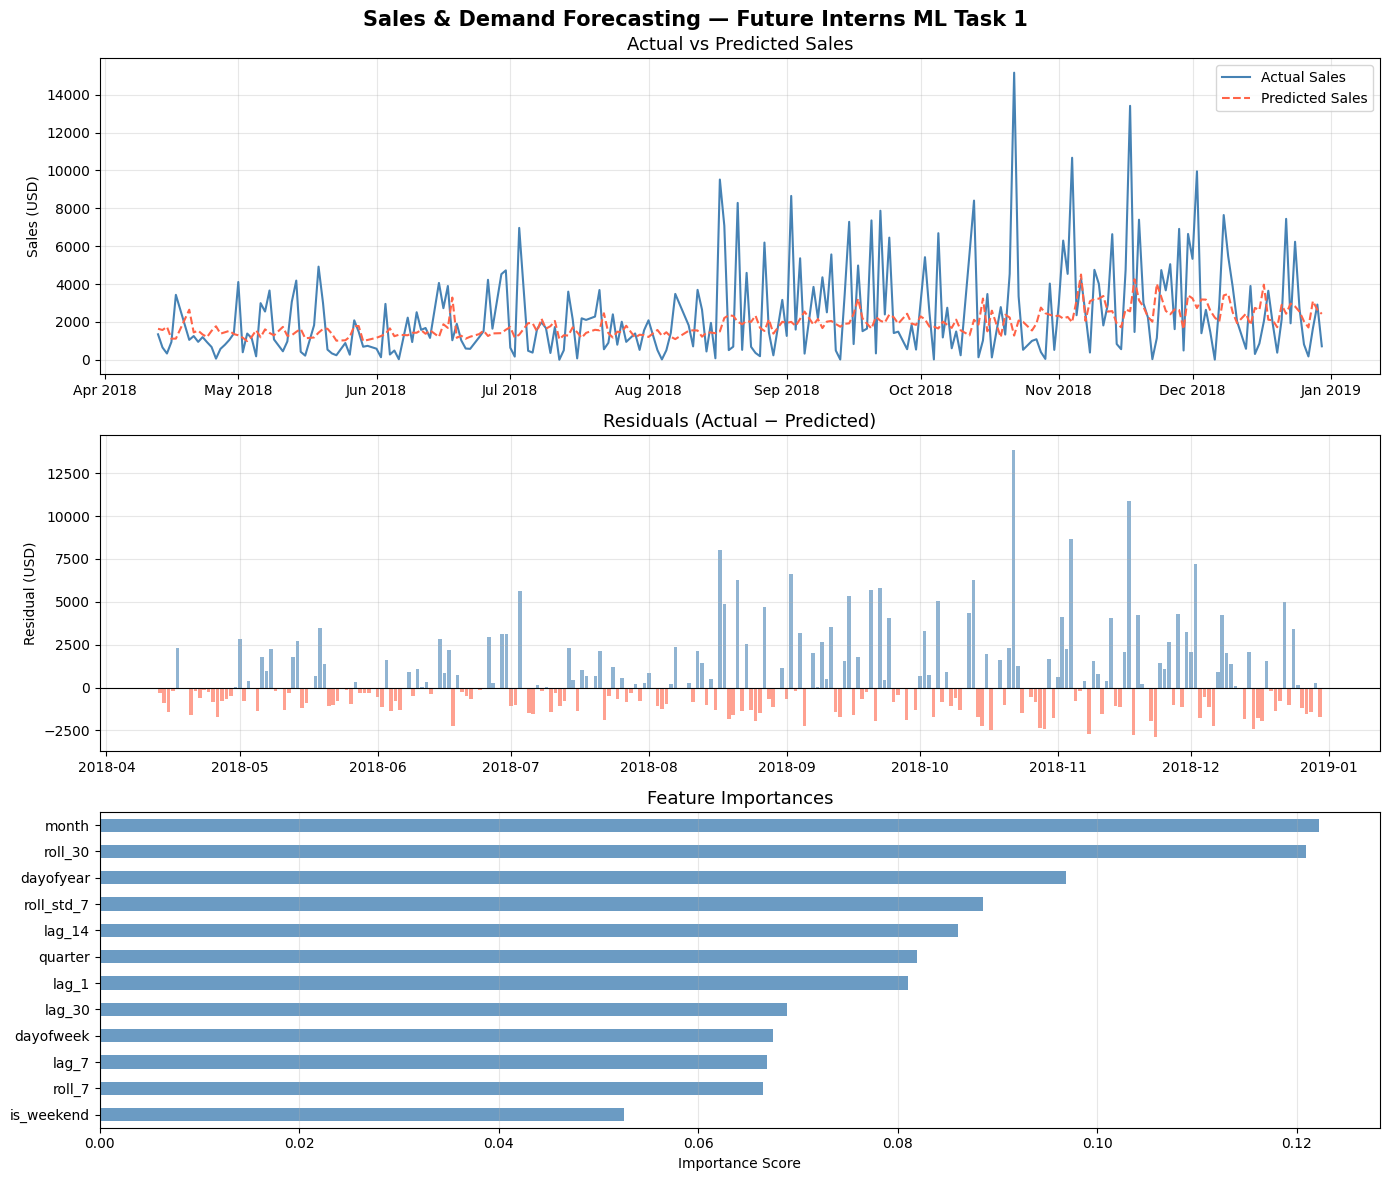

✅ forecast_report.png saved to Desktop


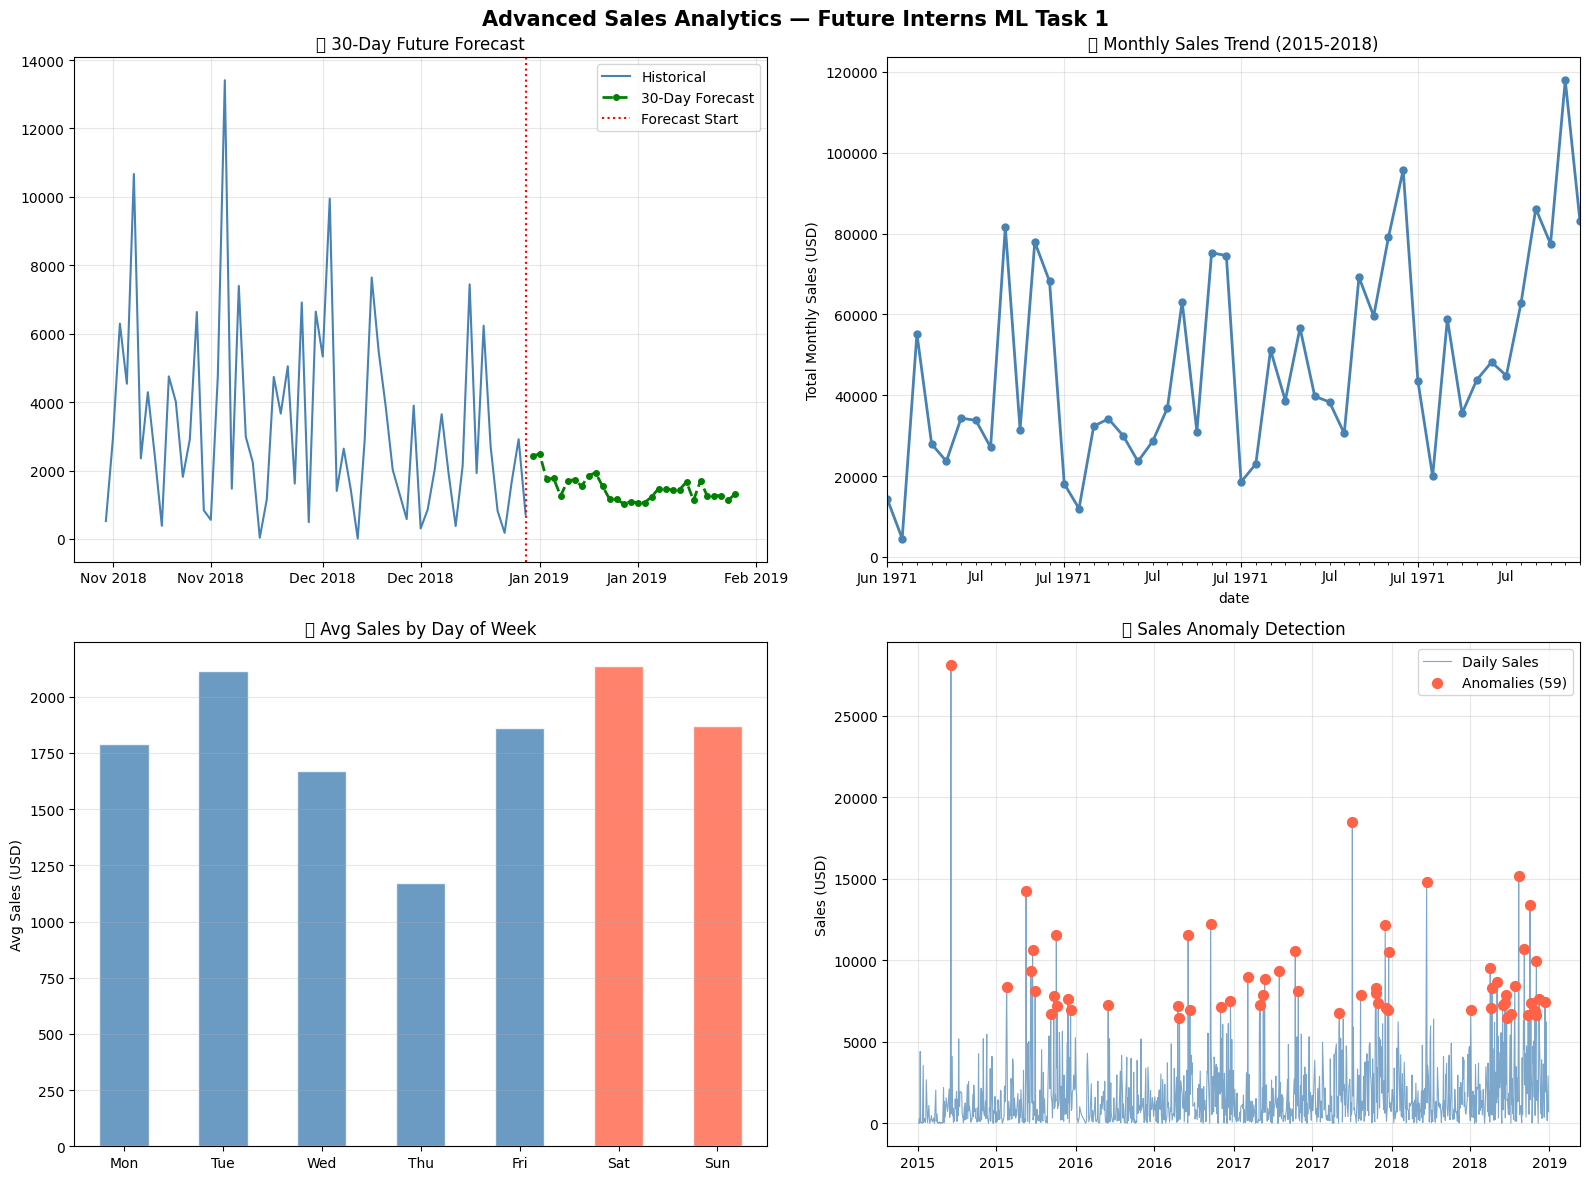

✅ advanced_analytics.png saved to Desktop

🎉 Task 1 Complete! All outputs saved successfully.


In [5]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
df = pd.read_csv('C:/Users/ganes/OneDrive/Desktop/train.csv/train.csv',
                 parse_dates=['Order Date'], dayfirst=True)
df = df.groupby('Order Date')['Sales'].sum().reset_index()
df.columns = ['date', 'sales']
df = df.sort_values('date').set_index('date')
print(f"✅ Data loaded: {len(df)} rows | {df.index.min().date()} to {df.index.max().date()}")

# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
def make_features(df):
    d = df.copy()
    d['lag_1']      = d['sales'].shift(1)
    d['lag_7']      = d['sales'].shift(7)
    d['lag_14']     = d['sales'].shift(14)
    d['lag_30']     = d['sales'].shift(30)
    d['roll_7']     = d['sales'].shift(1).rolling(7).mean()
    d['roll_30']    = d['sales'].shift(1).rolling(30).mean()
    d['roll_std_7'] = d['sales'].shift(1).rolling(7).std()
    d['month']      = d.index.month
    d['quarter']    = d.index.quarter
    d['dayofweek']  = d.index.dayofweek
    d['dayofyear']  = d.index.dayofyear
    d['is_weekend'] = (d.index.dayofweek >= 5).astype(int)
    return d.dropna()

df_feat = make_features(df)
X = df_feat.drop('sales', axis=1)
y = df_feat['sales']
print(f"✅ Features created: {list(X.columns)}")

# ── TRAIN/TEST SPLIT ──────────────────────────────────────────────────────────
split = int(len(df_feat) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f"✅ Train: {len(X_train)} rows | Test: {len(X_test)} rows")

# ── TRAIN MODEL ───────────────────────────────────────────────────────────────
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("✅ Model trained successfully")

# ── EVALUATE ──────────────────────────────────────────────────────────────────
preds = model.predict(X_test)
mae   = mean_absolute_error(y_test, preds)
rmse  = np.sqrt(mean_squared_error(y_test, preds))
mask  = y_test > 50
mape  = np.mean(np.abs((y_test[mask] - preds[mask]) / y_test[mask])) * 100

print("\n✅ Model Evaluation")
print("=" * 35)
print(f"  MAE:           ${mae:,.2f}")
print(f"  RMSE:          ${rmse:,.2f}")
print(f"  MAPE:          {mape:.2f}%")
print(f"  Training rows: {len(X_train)}")
print(f"  Test rows:     {len(X_test)}")

# ── ANOMALY DETECTION ─────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df['sales']))
anomalies = df[z_scores > 2]

print("\n🚨 Anomaly Detection — Unusual Sales Days")
print("=" * 45)
print(f"  Total anomalies found: {len(anomalies)}")
print(f"  Highest spike: ${anomalies['sales'].max():,.2f} on {anomalies['sales'].idxmax().date()}")
print(f"  Lowest drop:   ${anomalies['sales'].min():,.2f} on {anomalies['sales'].idxmin().date()}")
print("\n  Top 5 Unusual Sales Days:")
print(anomalies.sort_values('sales', ascending=False).head())

# ── FUTURE 30-DAY FORECAST ────────────────────────────────────────────────────
print("\n🔮 Future 30-Day Sales Forecast (Beyond Dataset)")
print("=" * 45)

future_df = df.copy()
future_preds = []
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1), periods=30)

for date in future_dates:
    temp = make_features(future_df)
    last_row = temp.iloc[[-1]].drop('sales', axis=1)
    pred = model.predict(last_row)[0]
    future_preds.append(pred)
    new_row = pd.DataFrame({'sales': [pred]}, index=[date])
    future_df = pd.concat([future_df, new_row])

future_series = pd.Series(future_preds, index=future_dates)
print(future_series.to_string())
print(f"\n  Avg predicted daily sales (next 30 days): ${future_series.mean():,.2f}")
print(f"  Total predicted revenue (next 30 days):   ${future_series.sum():,.2f}")

# ── BUSINESS INSIGHTS ─────────────────────────────────────────────────────────
print("\n💡 Smart Business Insights")
print("=" * 45)

monthly = df.resample('ME')['sales'].sum()
best_month = monthly.idxmax().strftime('%B %Y')
worst_month = monthly.idxmin().strftime('%B %Y')
avg_weekday = df.groupby(df.index.dayofweek)['sales'].mean()
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
best_day = day_names[avg_weekday.idxmax()]
worst_day = day_names[avg_weekday.idxmin()]

print(f"  📈 Best sales month:  {best_month} (${monthly.max():,.2f})")
print(f"  📉 Worst sales month: {worst_month} (${monthly.min():,.2f})")
print(f"  📅 Best sales day:    {best_day} (avg ${avg_weekday.max():,.2f})")
print(f"  📅 Worst sales day:   {worst_day} (avg ${avg_weekday.min():,.2f})")
print(f"  🎯 Revenue growth 2015→2018: ${(monthly.iloc[-1] - monthly.iloc[0]):,.2f}")

# ── BUSINESS SUMMARY ──────────────────────────────────────────────────────────
print("\n📊 Business Forecast Summary")
print("=" * 45)
print(f"  Forecast period:    {y_test.index[0].date()} to {y_test.index[-1].date()}")
print(f"  Avg actual sales:   ${y_test.mean():,.2f}/day")
print(f"  Avg forecast sales: ${preds.mean():,.2f}/day")
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n  🔍 Top 3 Most Important Features:")
for feat, score in feat_imp.head(3).items():
    print(f"    {feat}: {score:.4f}")

# ── CHART 1: MAIN FORECAST CHARTS ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Sales & Demand Forecasting — Future Interns ML Task 1',
             fontsize=15, fontweight='bold')

axes[0].plot(y_test.index, y_test.values,
             label='Actual Sales', color='steelblue', linewidth=1.5)
axes[0].plot(y_test.index, preds,
             label='Predicted Sales', color='tomato', linewidth=1.5, linestyle='--')
axes[0].set_title('Actual vs Predicted Sales', fontsize=13)
axes[0].set_ylabel('Sales (USD)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

residuals = y_test.values - preds
axes[1].bar(y_test.index, residuals,
            color=['tomato' if r < 0 else 'steelblue' for r in residuals], alpha=0.6)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuals (Actual − Predicted)', fontsize=13)
axes[1].set_ylabel('Residual (USD)')
axes[1].grid(alpha=0.3)

feat_imp_plot = feat_imp.sort_values(ascending=True)
feat_imp_plot.plot(kind='barh', ax=axes[2], color='steelblue', alpha=0.8)
axes[2].set_title('Feature Importances', fontsize=13)
axes[2].set_xlabel('Importance Score')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('C:/Users/ganes/OneDrive/Desktop/forecast_report.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ forecast_report.png saved to Desktop")

# ── CHART 2: ADVANCED ANALYTICS ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced Sales Analytics — Future Interns ML Task 1',
             fontsize=15, fontweight='bold')

axes[0,0].plot(df.index[-60:], df['sales'].values[-60:],
               label='Historical', color='steelblue', linewidth=1.5)
axes[0,0].plot(future_series.index, future_series.values,
               label='30-Day Forecast', color='green',
               linewidth=2, linestyle='--', marker='o', markersize=4)
axes[0,0].axvline(x=df.index[-1], color='red',
                  linestyle=':', linewidth=1.5, label='Forecast Start')
axes[0,0].set_title('🔮 30-Day Future Forecast', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

monthly.plot(ax=axes[0,1], color='steelblue',
             linewidth=2, marker='o', markersize=5)
axes[0,1].set_title('📅 Monthly Sales Trend (2015-2018)', fontsize=12)
axes[0,1].set_ylabel('Total Monthly Sales (USD)')
axes[0,1].grid(alpha=0.3)
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_weekday_plot = df.groupby(df.index.dayofweek)['sales'].mean()
avg_weekday_plot.index = day_labels
colors = ['tomato' if d in ['Sat','Sun'] else 'steelblue' for d in day_labels]
avg_weekday_plot.plot(kind='bar', ax=axes[1,0], color=colors,
                      alpha=0.8, edgecolor='white')
axes[1,0].set_title('📊 Avg Sales by Day of Week', fontsize=12)
axes[1,0].set_ylabel('Avg Sales (USD)')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].grid(alpha=0.3, axis='y')

axes[1,1].plot(df.index, df['sales'], color='steelblue',
               linewidth=0.8, alpha=0.7, label='Daily Sales')
axes[1,1].scatter(anomalies.index, anomalies['sales'],
                  color='tomato', s=50, zorder=5, label=f'Anomalies ({len(anomalies)})')
axes[1,1].set_title('🚨 Sales Anomaly Detection', fontsize=12)
axes[1,1].set_ylabel('Sales (USD)')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('C:/Users/ganes/OneDrive/Desktop/advanced_analytics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ advanced_analytics.png saved to Desktop")
print("\n🎉 Task 1 Complete! All outputs saved successfully.")

In [6]:
import os
for root, dirs, files in os.walk('C:/Users/ganes'):
    for file in files:
        if file.endswith('.ipynb'):
            print(os.path.join(root, file))

C:/Users/ganes\sales_forecasting.ipynb
C:/Users/ganes\.ipynb_checkpoints\sales_forecasting-checkpoint.ipynb
C:/Users/ganes\.vscode\extensions\ms-python.python-2026.4.0-win32-x64\python_files\Notebooks intro.ipynb
C:/Users/ganes\Downloads\.ipynb_checkpoints\sales_forecasting-checkpoint.ipynb
